In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pyref.fitting as fit

from utils import models_root

/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
with open(models_root / "xrr/znpc/dft/dft_en_offset_new2.pkl", "rb") as f:
    dft_constraint = pickle.load(f)

print(dft_constraint.logp())

-37.821832213508245


Surface_283.7
Contamination_283.7
Oxide_283.7
Substrate_283.7


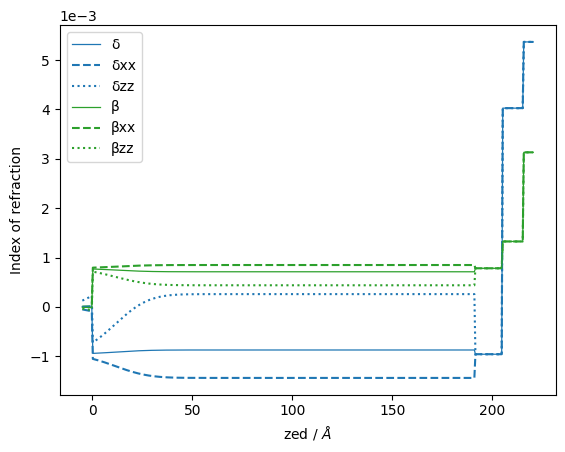

In [3]:
from pyref.fitting import LogpExtra

magic_angle = np.radians(54.73561031724)

def interface_constraint_fix(thickness, roughness) -> tuple[float, float]:
    """
    Return a valid (thickness, roughness) pair such that
    sqrt(2*pi) * roughness < thickness, by moving both to
    the minimal adjustment where they meet in the middle.
    """
    factor = np.sqrt(2 * np.pi)
    if thickness > factor * roughness:
        return thickness, roughness
    # We want thickness == factor * roughness,
    # so solve: thickness + x = factor*(roughness + x)
    # => thickness + x = factor*roughness + factor*x
    # => thickness - factor*roughness = (factor-1)*x
    # => x = (thickness - factor*roughness) / (factor - 1)
    x = (factor * roughness - thickness) / (factor + 1)
    new_thickness = thickness + x
    new_roughness = roughness + x
    return new_thickness, 0

def fix_interfaces(o):
    for slab in o.model.structure:
        wid = np.sqrt(2*np.pi) * slab.rough
        if wid > slab.thick:
            print(slab.name)
            thick, rough = interface_constraint_fix(slab.thick.value, slab.rough.value)
            slab.thick.setp(value=thick, bounds=(slab.thick.bounds.lb, thick+1))
            slab.rough.setp(value=rough, bounds=(slab.rough.bounds.lb, rough+1))
    return True

for o in dft_constraint.objectives:
    if o.model.energy == 283.7:
        fix_interfaces(o)

        interface = o.model.structure[3]
        interface.sld.rotation.setp(value=magic_angle, bounds=(0, magic_angle))
        interface.sld.density.setp(bounds=(.5, 1.8))
        # # interface.rough.setp(value=19)
        # # interface.thick.setp(value=interface_constraint_fix(interface.thick.value, interface.rough.value))

        # # Let's do the same for the surface interface
        surface = o.model.structure[1]
        surface.sld.rotation.setp(value=magic_angle, bounds=(0, np.pi/2))
        surface.sld.density.setp(bounds=(.5, 1.8))
        # surface.rough.setp(value=19)
        # surface.thick.setp(value=interface_constraint_fix(surface.thick.value, surface.rough.value))
        o.logp_extra = LogpExtra(o)
        o.model.structure.plot()
        break


In [5]:
test_fitter = fit.CurveFitter(dft_constraint)

test_fitter.fit(target="nlpost", options={"workers": -1})

0it [00:00, ?it/s]

: 

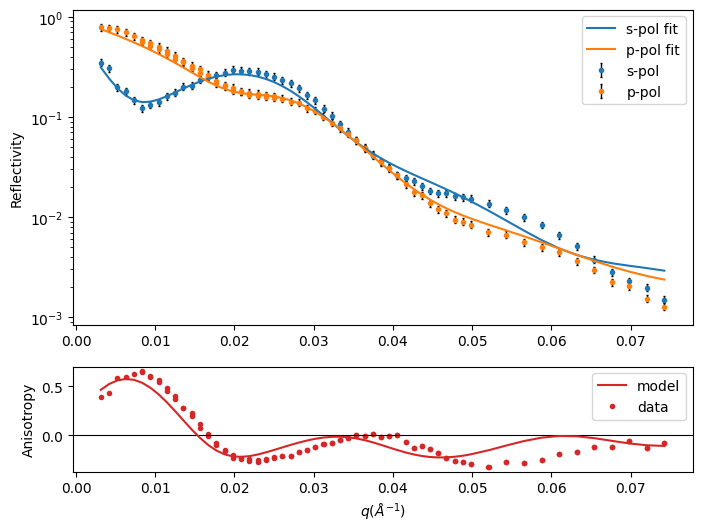

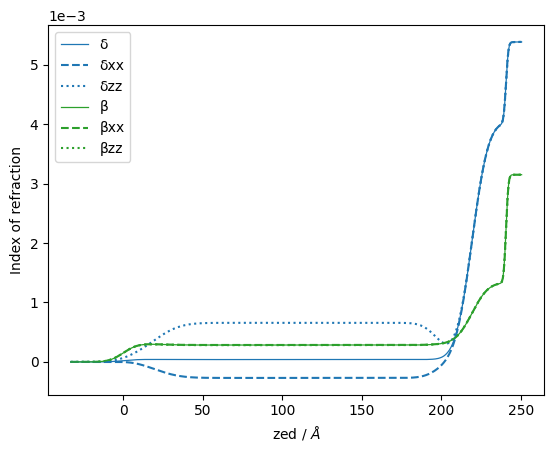

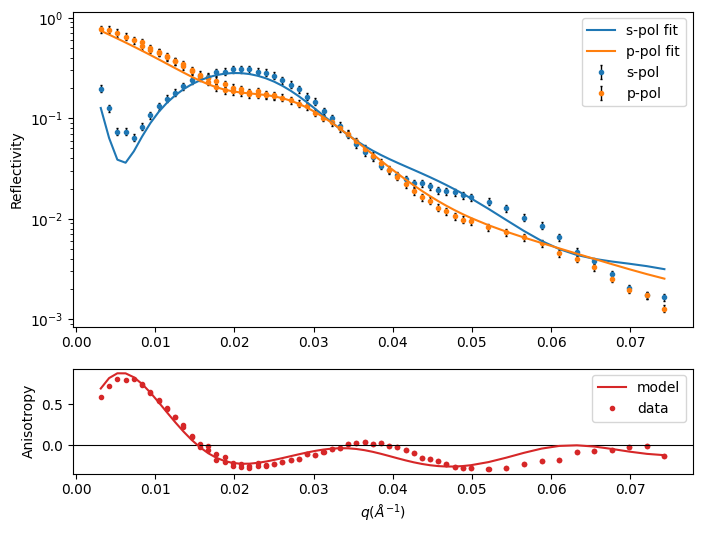

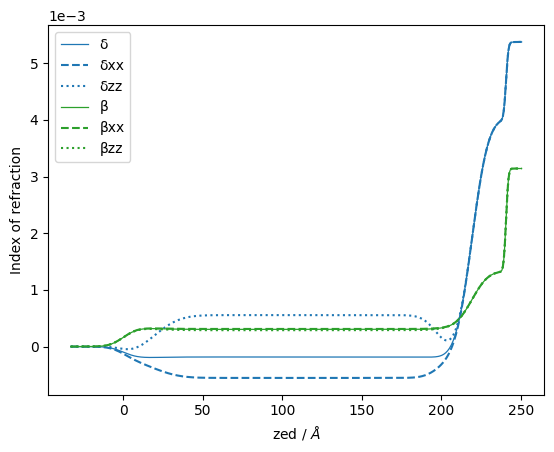

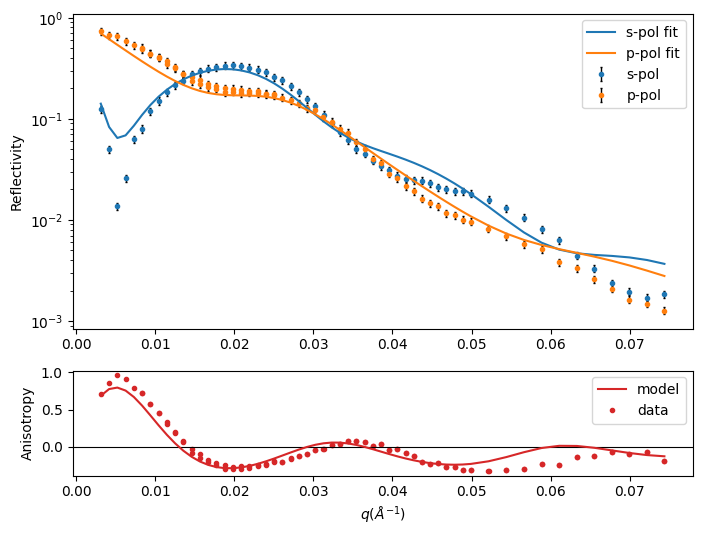

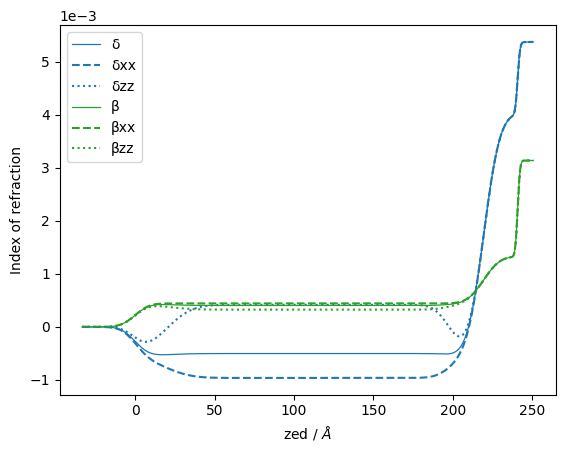

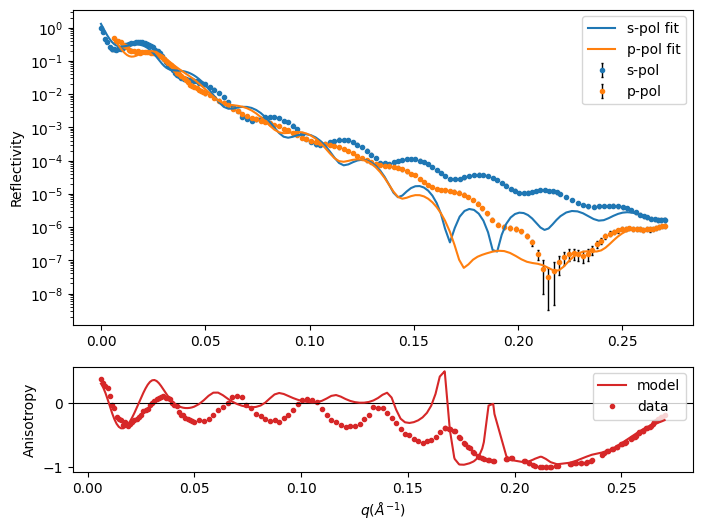

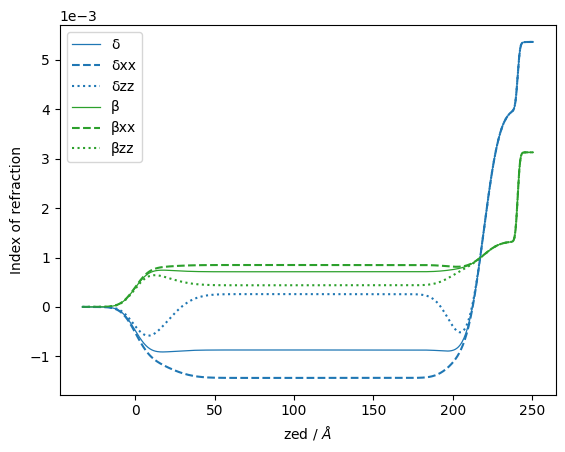

18.686823475177924 179.9514730957673 20.783396262423224
7.056021690245074 13.136336626059903 7.8924332190163025
54.73561031724001 69.5386131909103 54.73561031724001


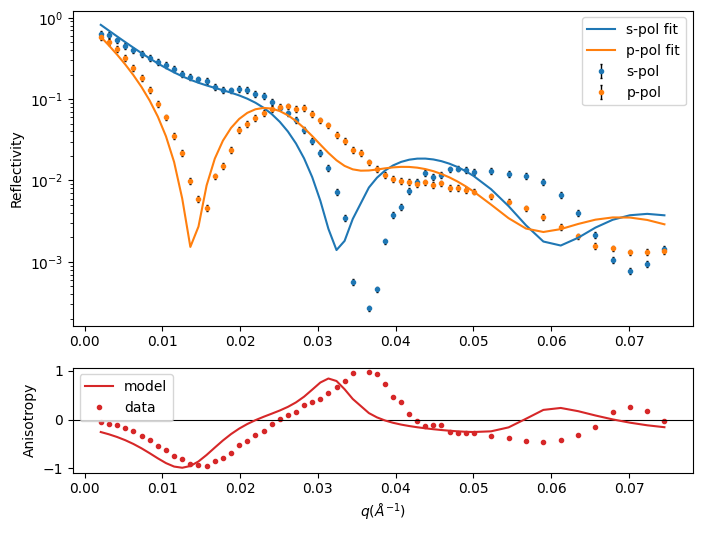

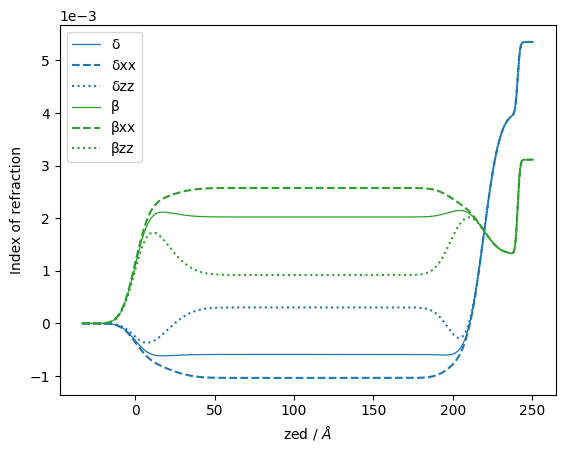

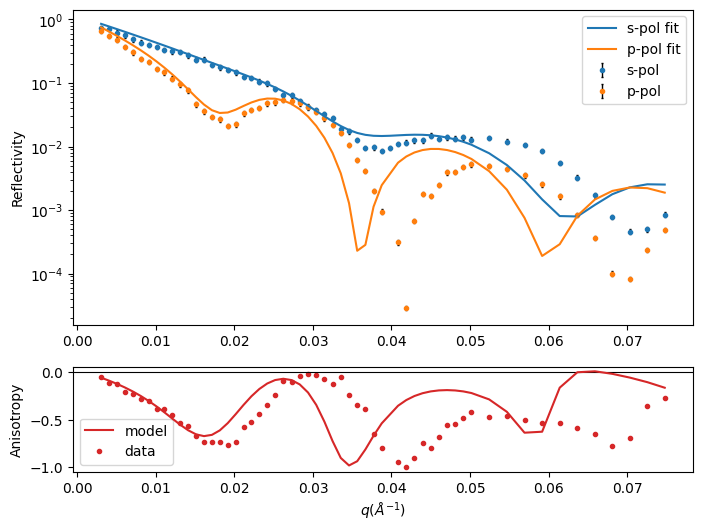

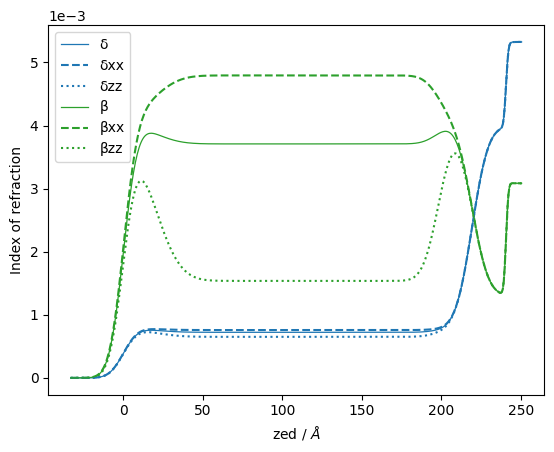

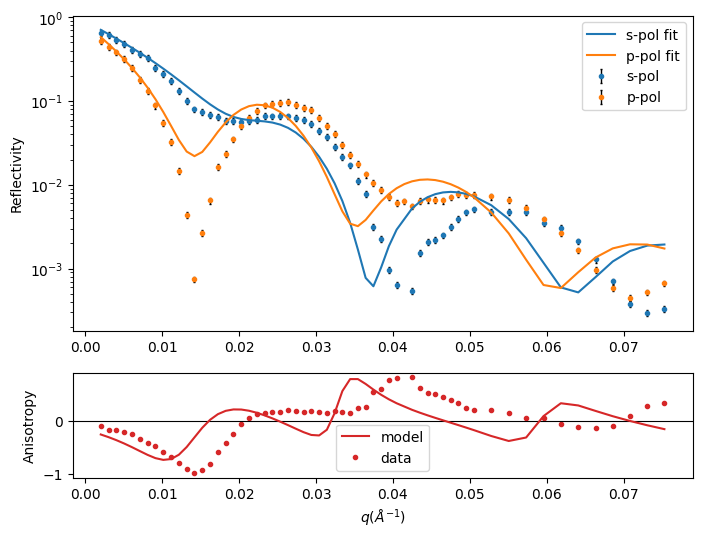

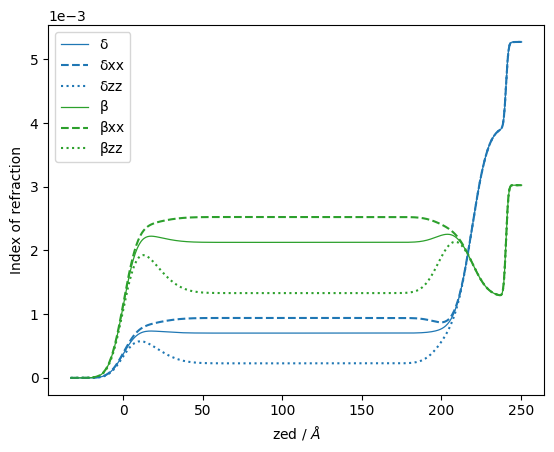

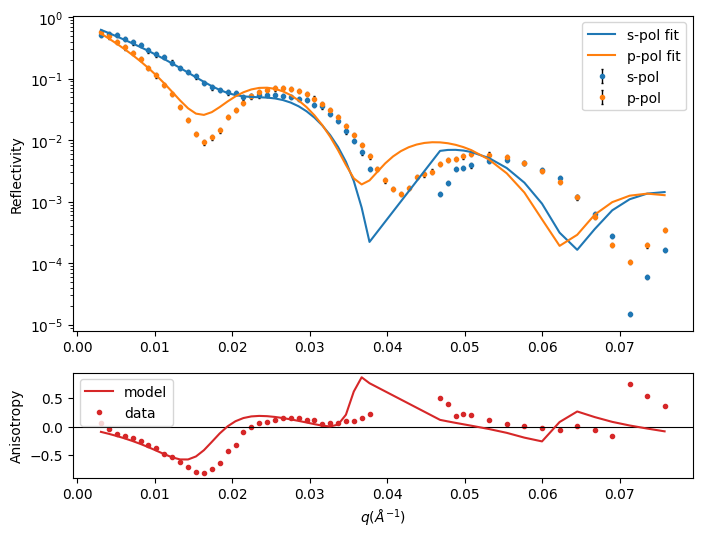

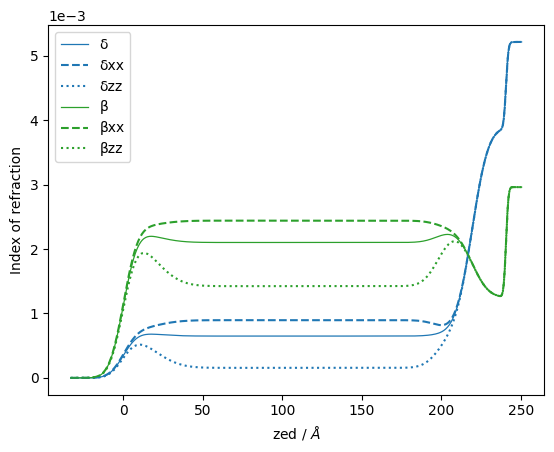

In [35]:
import matplotlib.pyplot as plt

for o in test_fitter.objective.objectives:
    if o.model.energy >= 283:
        o.plot()
        plt.show()
        o.model.structure.plot()
        plt.show()
        if o.model.energy == 283.7:
            print(
                o.model.structure[1].thick.value,
                o.model.structure[2].thick.value,
                o.model.structure[3].thick.value,
            )
            print(
                o.model.structure[1].rough.value,
                o.model.structure[2].rough.value,
                o.model.structure[3].rough.value,
            )
            print(
                o.model.structure[1].sld.rotation.value * 180 / np.pi,
                o.model.structure[2].sld.rotation.value * 180 / np.pi,
                o.model.structure[3].sld.rotation.value * 180 / np.pi,
            )

In [33]:
with open(models_root / "xrr/dft/dft_en_offset_new.pkl", "wb") as f:
    pickle.dump(test_fitter.objective, f)
